**MOMENTS**

If you consider a linear SISO system, described by the form: 

\begin{align}
\dot{x} &= Ax + Bu \\
y &= Cx
\end{align}

The transfer function is given by: 
\begin{equation}
W(s) = C(sI - A)^{-1} B
\end{equation}

One can define the 0-moment of the system at $s^* \in \mathbf{C}$ as: 
\begin{equation}
\eta_0 (s^*) = C(s^* I - A)^{-1} B
\end{equation}

The k-moment of the system at $s^* \in \mathbf{C}$ is the complex number: 
\begin{equation}
\eta_k ( s^* ) = \frac{ (-1)^k }{ k !} \left[ \frac{d^k}{ds^k} ( C(sI -A )^{-1} B) \right]
\end{equation}

As shown by Astolfi (1), 
There is a 1 to 1 relationship between each moments and the matrix $C \Pi$. 

$$ \tilde{x}_g = \tilde{\Pi}_g \chi_g \quad (\text{dimension } N_g - n)$$


In [98]:
import numpy as np
import scipy.linalg as la

# Simple 2nd-order plant
A = np.array([[0., 1.],
              [-2., -3.]])
B = np.array([[0.],
              [1.]])
C = np.array([[1., 0.]])

# Signal generator (forward moments)
Sg = np.array([[0., 1.],
               [-1., 0.]])  # sinusoidal oscillator (cos,sin)
Lg = np.array([[1., 0.]])   # input = first component of generator

# Solve Sylvester for Pi_g: A Pi_g + B Lg = Pi_g Sg
Pi_g = la.solve_sylvester(A, -Sg, -B @ Lg)
Mg = C @ Pi_g

# Output filter (backward moments)
Sf = np.array([[-5.]])   # stable 1st-order filter
Lf = np.array([[1.]])    # feed output directly

# Solve Sylvester for Pi_f: Pi_f A + Lf C = S_f Pi_f
Pi_f = la.solve_sylvester(A.T, -Sf.T, -(C.T @ Lf.T))
Pi_f = Pi_f.T  # adjust orientation
Mf = Pi_f @ B

Pi_g, Mg, Pi_f, Mf


(array([[ 0.1, -0.3],
        [ 0.3,  0.1]]),
 array([[ 0.1, -0.3]]),
 array([[-0.16666667,  0.08333333]]),
 array([[0.08333333]]))

Let us consider a simple 2nd-order system, with a 3rd order signal generator. 

\begin{equation}
\ddot{x} + 2 \gamma \dot{x} + \omega ^ 2 x = u
\end{equation}

In state space form:
\begin{align}
\dot{x} &= Ax + Bu \in \mathbf{R^2}\\
y &= Cx \in \mathbf{R}
\end{align}

SYSTEM SETUP AND VALUE OF MOMENTS

In [99]:
w = np.sqrt(3)
gamma = 0.85

A = np.array([[0.,1.0],
             [ -w**2, -2 * gamma]])

B = np.array([[0.],
              [1.0]])

C = np.array([[1., 0.]])

# Signal generator (forward moments)
Sg = np.array([[-0.05, 0., 0.],
               [0., -0.05, -3.0],
               [0., 3.0, -0.5]])  

print(np.linalg.eigvals(Sg))
print(np.linalg.eigvals(A))

Lg = np.array([[0., 3.0, 3.0]])   # input = first component of generator

# Solve Sylvester for Pi_g: A Pi_g + B Lg = Pi_g Sg
Pi_g = la.solve_sylvester(A, -Sg, -B @ Lg)
Mg = C @ Pi_g

print(Pi_g)
print( Mg)

[-0.275+2.9915506j -0.275-2.9915506j -0.05 +0.j       ]
[-0.85+1.50913883j -0.85-1.50913883j]
[[ 0.         -0.57928411 -0.15173785]
 [ 0.         -0.42624935  1.81372125]]
[[ 0.         -0.57928411 -0.15173785]]


simulating the dynamics

Text(0, 0.5, 'C (x - Pi_g wg)')

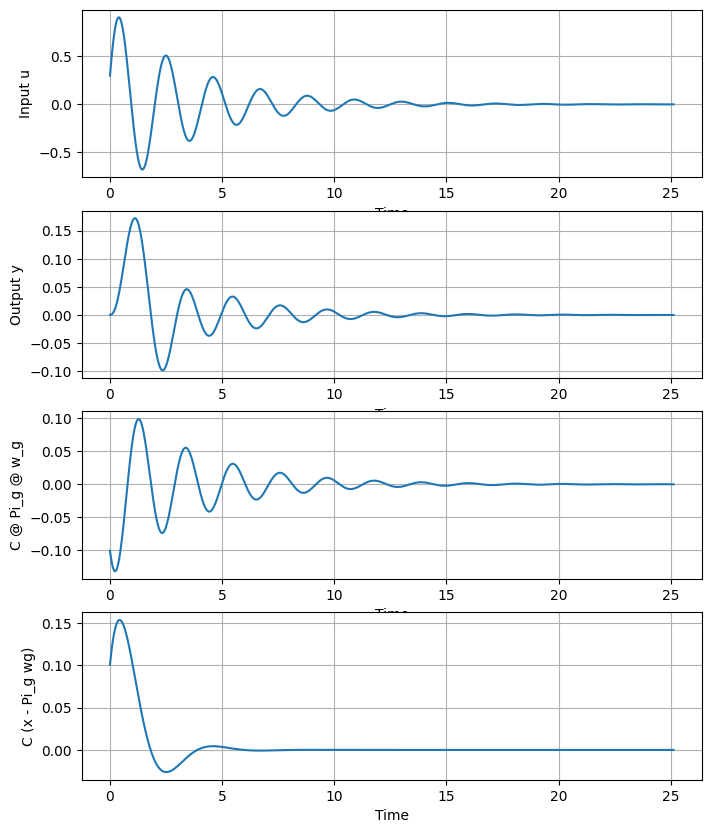

In [ ]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

t_span = (0., 8.0*np.pi)
t_eval = np.linspace(t_span[0], t_span[1], 10000)


def combined_dynamics(t, state):
    wg = state[:3]
    x = state[3:5]
    u = Lg @ wg
    dwg = Sg @ wg
    dx = A @ x + B.flatten() * u
    return np.concatenate([dwg, dx])

x0 = [1.0, 0.2, -0.1, 0., 0.]

sol = solve_ivp(combined_dynamics, t_span, x0, t_eval=t_eval, method='RK45')

Wg = sol.y[:3, :]
U = (Lg @ Wg)
Uflat = U.flatten()

X = sol.y[3:, :]
Y = C @ X
Yflat = Y.flatten()

# Pi_g wg
Piw = Pi_g @ Wg
Ypi = C @ Piw
Ypiflat = Ypi.flatten()

plt.figure(figsize=(8,10))
plt.subplot(4,1,1)
plt.plot(sol.t, Uflat)
plt.xlabel("Time")
plt.ylabel("Input u")
plt.grid(True)

plt.subplot(4,1,2)
plt.plot(sol.t, Yflat)
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Output y")

plt.subplot(4,1,3)
plt.plot(sol.t, Ypiflat)
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("C @ Pi_g @ w_g")

plt.subplot(4,1,4)
plt.plot(sol.t, Yflat - Ypiflat)
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("C (x - Pi_g wg)")





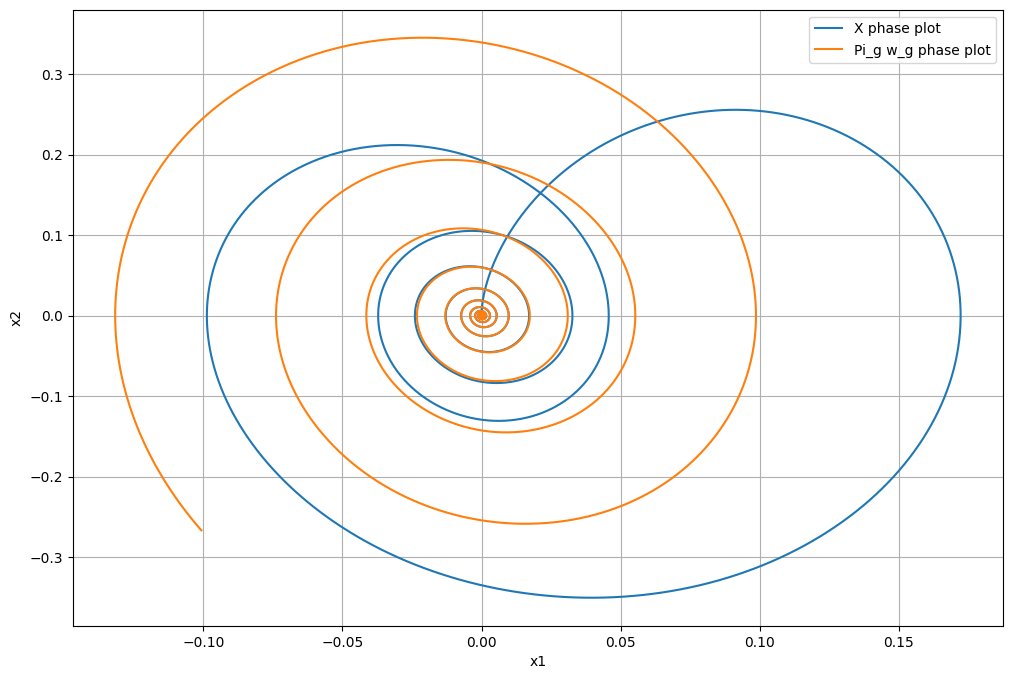

In [101]:
# phase plane plot

C2 = np.array( [[0., 1.0]] )
x1 = Yflat
x2 = (C2 @ X).flatten()

z1 = Ypiflat
z2 = (C2 @ Piw).flatten()

plt.figure(figsize=(12,8))
plt.plot(x1, x2, label = 'X phase plot')
plt.plot(z1, z2, label = 'Pi_g w_g phase plot')
plt.legend()
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

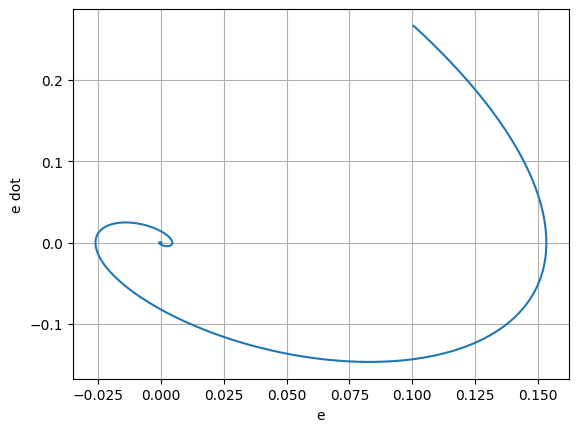

In [102]:
u1 = ( C @ (X - Piw)).flatten()
u2 = ( C2 @ ( X - Piw )).flatten()

plt.plot(u1, u2)
plt.grid(True)
plt.xlabel("e")
plt.ylabel("e dot")
plt.show()